## 1. Imports and Load Enriched Dataset

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

In [ ]:
# Load the enriched dataset
data = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Data"
)

impact_links = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Impact_sheet"
)

# Convert date columns
date_columns = [
    "observation_date",
    "period_start",
    "period_end",
    "collection_date"
]

for col in date_columns:
    if col in data.columns:
        data[col] = pd.to_datetime(
            data[col],
            errors="coerce"
        )

print("Data shape:", data.shape)
print("Impact links shape:", impact_links.shape)

display(data.head())

Data shape: (57, 34)
Impact links shape: (24, 35)


C:\Users\hp\AppData\Local\Temp\ipykernel_8904\710639866.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,Gender disaggregated,NaN


## 2. Dataset Overview

### 2.1 Summary by Record Type

In [3]:
record_type_summary = (
    data["record_type"]
    .value_counts()
    .rename_axis("record_type")
    .reset_index(name="count")
)

display(record_type_summary)

,record_type,count
0,observation,38
1,event,12
2,target,3
3,milestone,2
4,policy,1
5,infrastructure,1


### Visualization


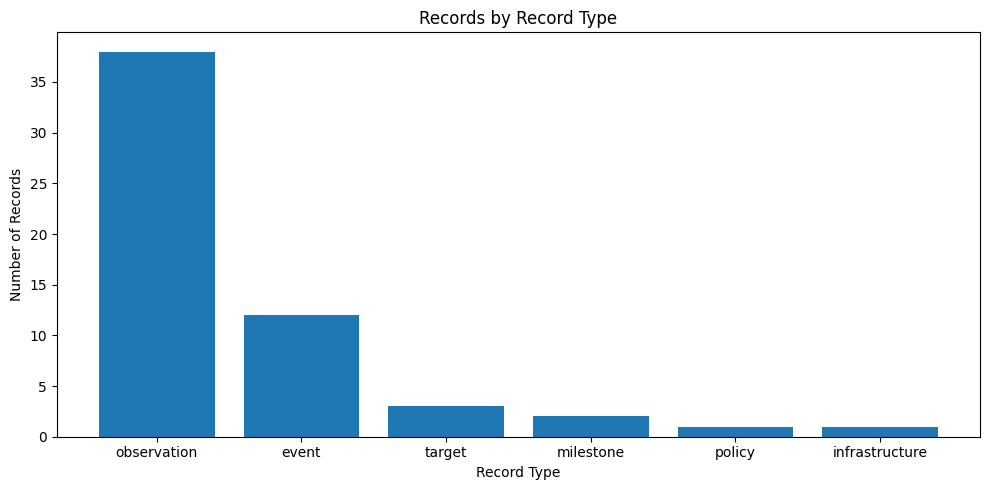

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    record_type_summary["record_type"],
    record_type_summary["count"]
)

plt.title("Records by Record Type")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### 2.2 Summary by Pillar

In [13]:
pillar_summary = (
    data["pillar"]
    .value_counts(dropna=False)
    .rename_axis("pillar")
    .reset_index(name="count")
)

display(pillar_summary)

,pillar,count
0,ACCESS,21
1,NaN,16
2,USAGE,14
3,GENDER,5
4,AFFORDABILITY,1


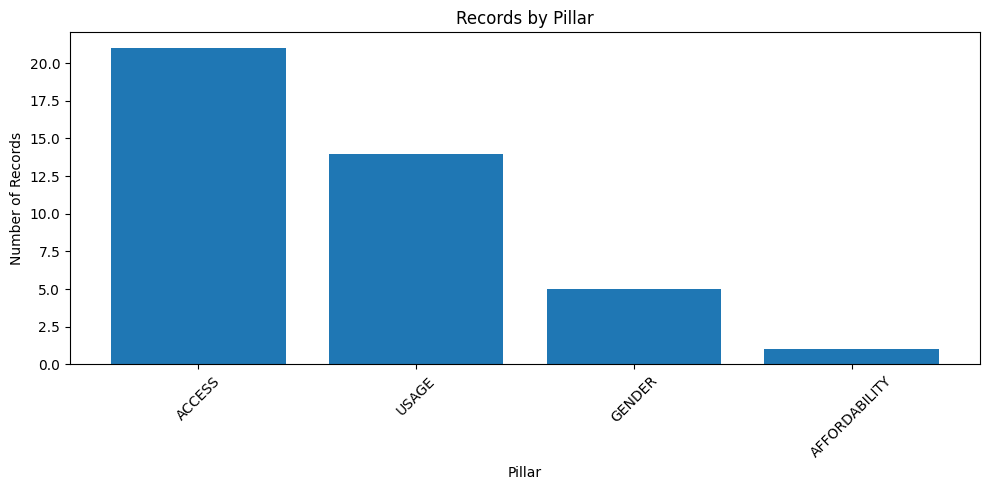

In [14]:
# Exclude missing pillar values for visualization
pillar_plot = (
    data["pillar"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10, 5))

plt.bar(
    pillar_plot.index,
    pillar_plot.values
)

plt.title("Records by Pillar")
plt.xlabel("Pillar")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 2.3 Summary by Source Type

In [15]:
source_summary = (
    data["source_type"]
    .value_counts(dropna=False)
    .rename_axis("source_type")
    .reset_index(name="count")
)

display(source_summary)

,source_type,count
0,operator,23
1,regulator,11
2,survey,10
3,policy,5
4,research,4
5,calculated,2
6,news,2


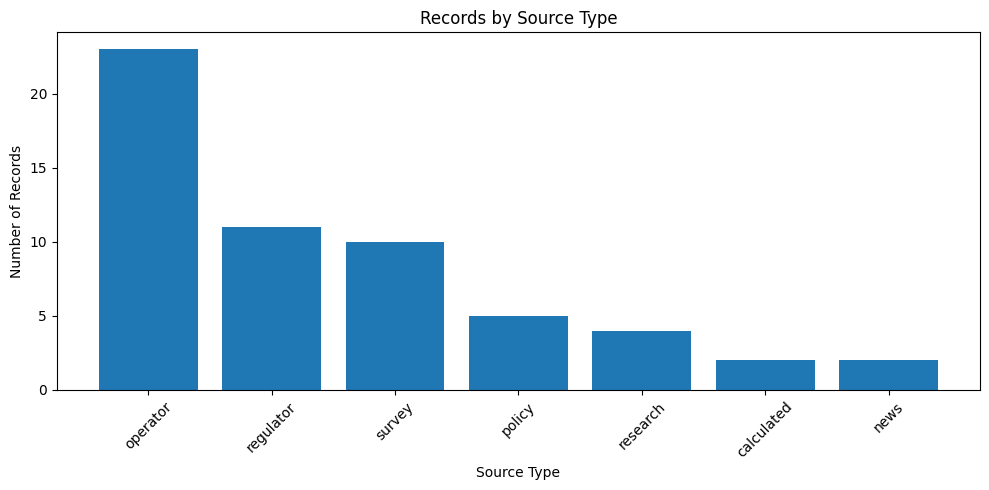

In [16]:
source_plot = (
    data["source_type"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(10, 5))

plt.bar(
    source_plot.index,
    source_plot.values
)

plt.title("Records by Source Type")
plt.xlabel("Source Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Temporal Coverage

### 3.1 Extract Year

In [17]:
data["year"] = data["observation_date"].dt.year

In [18]:
temporal_summary = (
    data[
        data["year"].notna()
    ]
    .groupby(["year", "record_type"])
    .size()
    .reset_index(name="count")
)

display(temporal_summary)

,year,record_type,count
0,2014,observation,1
1,2017,observation,1
2,2021,event,2
3,2021,observation,5
4,2022,event,1
5,2023,event,1
6,2023,observation,1
7,2024,event,4
8,2024,observation,13
9,2025,event,4


### 3.2 Which Years Have Data for Which Indicators?

In [19]:
indicator_years = (
    data[
        data["indicator_code"].notna()
        & data["year"].notna()
    ]
    .groupby("indicator_code")["year"]
    .agg(
        first_year="min",
        last_year="max",
        number_of_years="nunique"
    )
    .reset_index()
)

display(indicator_years)

,indicator_code,first_year,last_year,number_of_years
0,ACC_4G_COV,2023,2025,2
1,ACC_FAYDA,2024,2028,3
2,ACC_MM_ACCOUNT,2021,2024,2
3,ACC_MOBILE_PEN,2025,2025,1
4,ACC_OWNERSHIP,2014,2025,5
5,AFF_DATA_INCOME,2024,2024,1
6,EVT_CROSSOVER,2024,2024,1
7,EVT_ETHIOPAY,2025,2025,1
8,EVT_FAYDA,2024,2024,1
9,EVT_FX_REFORM,2024,2024,1


### 3.3 Indicator-Year Coverage Matrix

In [20]:
indicator_year_matrix = pd.pivot_table(
    data[
        data["indicator_code"].notna()
        & data["year"].notna()
    ],
    index="indicator_code",
    columns="year",
    values="value_numeric",
    aggfunc="first"
)

display(indicator_year_matrix)

year,2014,2017,2021,2023,2024,2025,2028,2030
indicator_code,,,,,,,,
ACC_4G_COV,NaN,NaN,NaN,37.5,NaN,7.080000e+01,NaN,NaN
ACC_FAYDA,NaN,NaN,NaN,NaN,8000000.00,1.200000e+07,90000000.0,NaN
ACC_MM_ACCOUNT,NaN,NaN,4.7,NaN,9.45,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,6.140000e+01,NaN,NaN
ACC_OWNERSHIP,22.0,35.0,46.0,NaN,49.00,7.000000e+01,NaN,NaN
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,2.00,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,20.0,NaN,18.00,NaN,NaN,NaN
GEN_GAP_MOBILE,NaN,NaN,NaN,NaN,24.00,NaN,NaN,NaN
GEN_MM_SHARE,NaN,NaN,NaN,NaN,14.00,NaN,NaN,50.0


### 3.4 Temporal Coverage Visualization

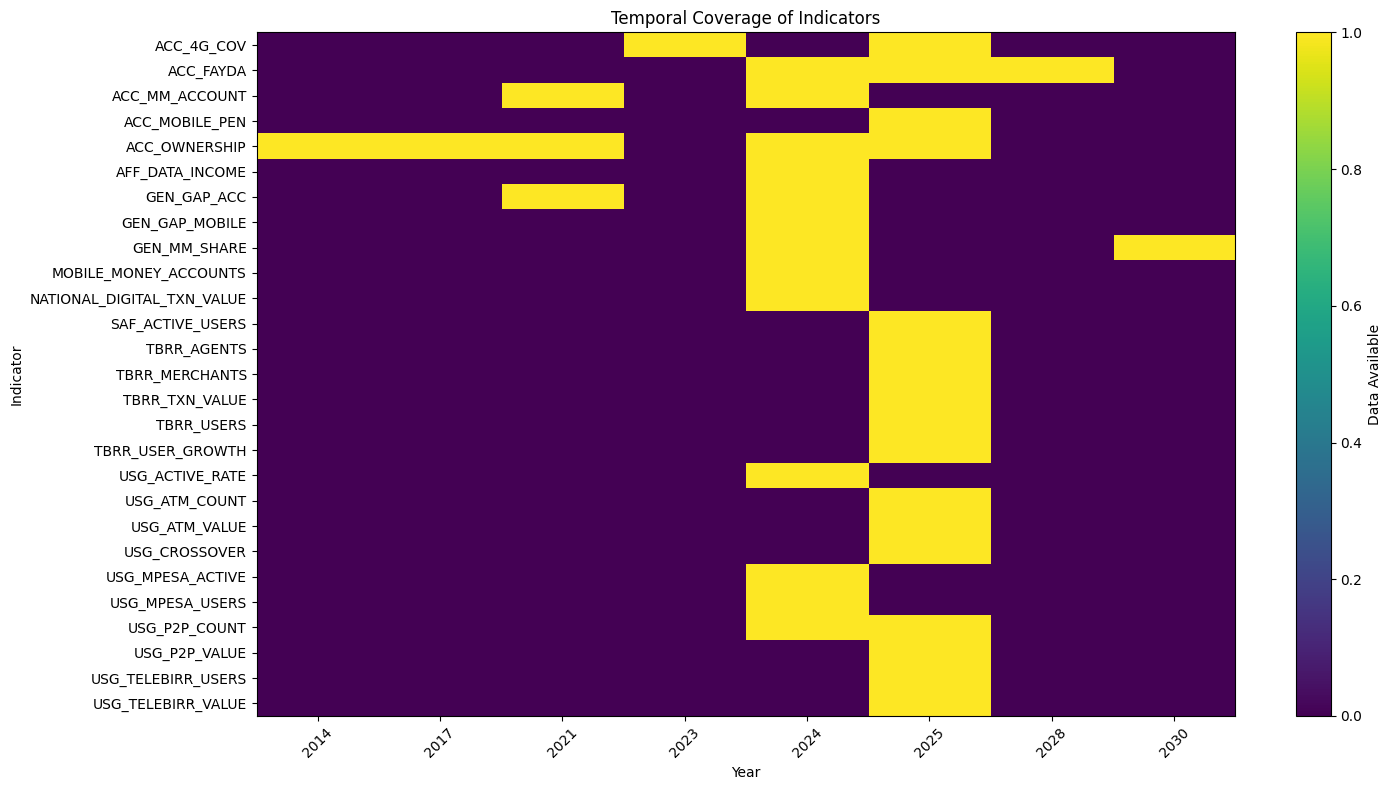

In [21]:
plt.figure(figsize=(15, 8))

plt.imshow(
    indicator_year_matrix.notna(),
    aspect="auto"
)

plt.colorbar(
    label="Data Available"
)

plt.xticks(
    ticks=np.arange(len(indicator_year_matrix.columns)),
    labels=indicator_year_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(indicator_year_matrix.index)),
    labels=indicator_year_matrix.index
)

plt.title("Temporal Coverage of Indicators")
plt.xlabel("Year")
plt.ylabel("Indicator")

plt.tight_layout()
plt.show()

## 4. Data Quality Assessment

### 4.1 Confidence Distribution

In [22]:
confidence_summary = (
    data["confidence"]
    .value_counts(dropna=False)
    .rename_axis("confidence")
    .reset_index(name="count")
)

display(confidence_summary)

,confidence,count
0,high,54
1,medium,3


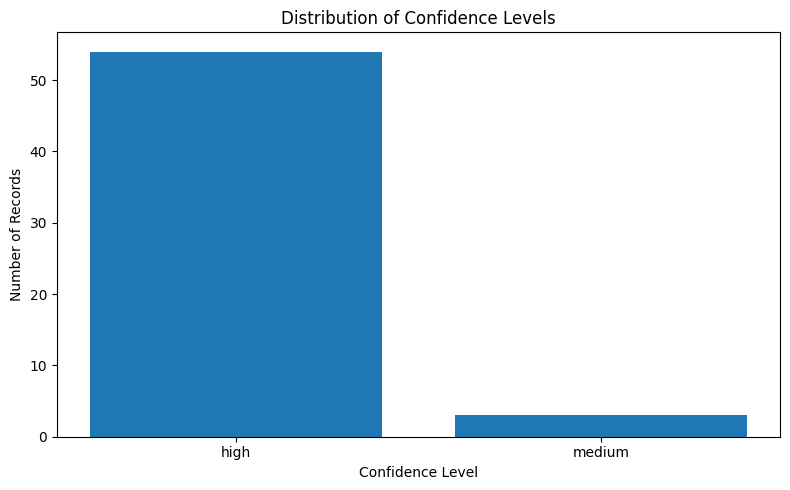

In [23]:
confidence_plot = (
    data["confidence"]
    .dropna()
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    confidence_plot.index,
    confidence_plot.values
)

plt.title("Distribution of Confidence Levels")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### 4.2 Confidence by Record Type


In [24]:
confidence_by_type = pd.crosstab(
    data["record_type"],
    data["confidence"]
)

display(confidence_by_type)

confidence,high,medium
record_type,,
event,12,0
infrastructure,1,0
milestone,2,0
observation,36,2
policy,1,0
target,2,1


## 5. Identify Sparse Indicators


In [25]:
indicator_coverage = (
    data[
        data["indicator_code"].notna()
    ]
    .groupby(
        [
            "indicator_code",
            "indicator"
        ],
        dropna=False
    )
    .agg(
        number_of_records=("record_id", "count"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        number_of_years=("year", "nunique")
    )
    .reset_index()
    .sort_values(
        "number_of_records"
    )
)

display(indicator_coverage)

,indicator_code,indicator,number_of_records,first_year,last_year,number_of_years
3,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,1
7,EVT_ETHIOPAY,EthioPay Instant Payment System Launch,1,2025,2025,1
6,EVT_CROSSOVER,P2P Transaction Count Surpasses ATM,1,2024,2024,1
5,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,1
11,EVT_MPESA_INTEROP,M-Pesa EthSwitch Integration,1,2025,2025,1
10,EVT_MPESA,M-Pesa Ethiopia Launch,1,2023,2023,1
9,EVT_FX_REFORM,Foreign Exchange Liberalization,1,2024,2024,1
8,EVT_FAYDA,Fayda Digital ID Program Rollout,1,2024,2024,1
12,EVT_NFIS2,NFIS-II Strategy Launch,1,2021,2021,1
13,EVT_SAFARICOM,Safaricom Ethiopia Commercial Launch,1,2022,2022,1


In [26]:
sparse_indicators = indicator_coverage[
    indicator_coverage["number_of_records"] <= 2
]

display(sparse_indicators)

,indicator_code,indicator,number_of_records,first_year,last_year,number_of_years
3,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,1
7,EVT_ETHIOPAY,EthioPay Instant Payment System Launch,1,2025,2025,1
6,EVT_CROSSOVER,P2P Transaction Count Surpasses ATM,1,2024,2024,1
5,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,1
11,EVT_MPESA_INTEROP,M-Pesa EthSwitch Integration,1,2025,2025,1
10,EVT_MPESA,M-Pesa Ethiopia Launch,1,2023,2023,1
9,EVT_FX_REFORM,Foreign Exchange Liberalization,1,2024,2024,1
8,EVT_FAYDA,Fayda Digital ID Program Rollout,1,2024,2024,1
12,EVT_NFIS2,NFIS-II Strategy Launch,1,2021,2021,1
13,EVT_SAFARICOM,Safaricom Ethiopia Commercial Launch,1,2022,2022,1


## 6. ACCESS ANALYSIS

### 6.1 Account Ownership Trajectory

In [27]:
account_ownership = data[
    (
        data["indicator_code"] == "ACC_OWNERSHIP"
    )
    &
    (
        data["value_numeric"].notna()
    )
].copy()

account_ownership = (
    account_ownership
    .sort_values("observation_date")
)

display(
    account_ownership[
        [
            "observation_date",
            "value_numeric",
            "gender",
            "location",
            "source_name"
        ]
    ]
)


,observation_date,value_numeric,gender,location,source_name
0,2014-12-31,22.0,all,national,Global Findex 2014
1,2017-12-31,35.0,all,national,Global Findex 2017
2,2021-12-31,46.0,all,national,Global Findex 2021
3,2021-12-31,56.0,male,national,Global Findex 2021
4,2021-12-31,36.0,female,national,Global Findex 2021
5,2024-11-29,49.0,all,national,Global Findex 2024
30,2025-12-31,70.0,all,national,NFIS-II Strategy


In [28]:
account_ownership_national = account_ownership[
    (
        account_ownership["gender"] == "all"
    )
    &
    (
        account_ownership["location"] == "national"
    )
].copy()

account_ownership_national = (
    account_ownership_national
    .sort_values("observation_date")
)

### 6.2 Plot Account Ownership

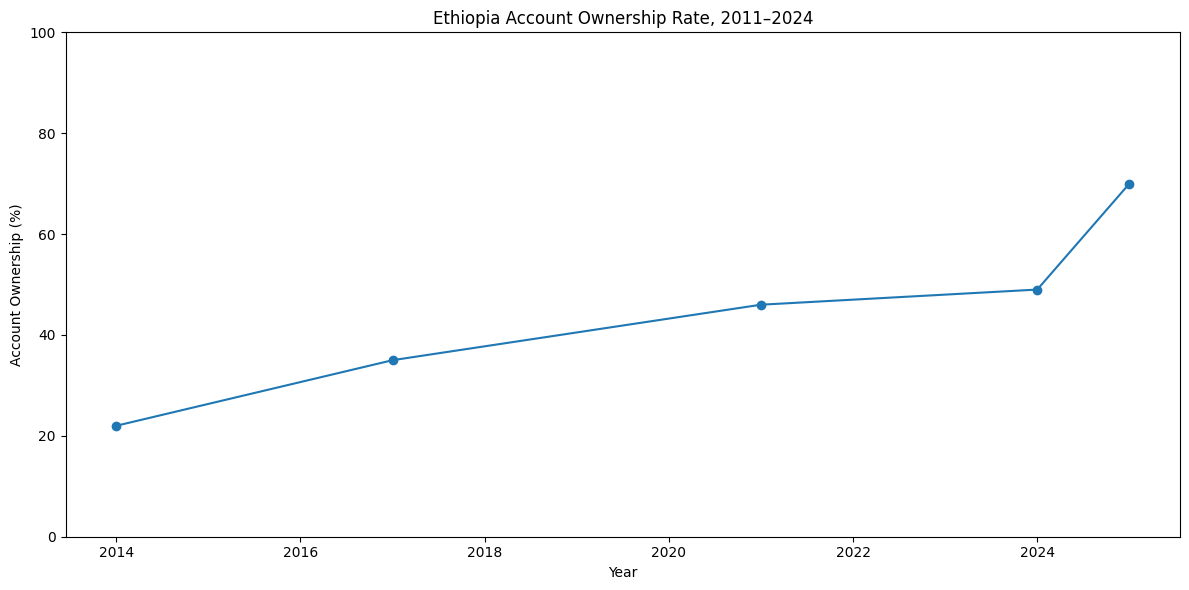

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    account_ownership_national["year"],
    account_ownership_national["value_numeric"],
    marker="o"
)

plt.title(
    "Ethiopia Account Ownership Rate, 2011–2024"
)

plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### 6.3 Calculate Growth Between Survey Years

In [30]:
account_ownership_national = (
    account_ownership_national
    .sort_values("year")
    .copy()
)

account_ownership_national["absolute_change_pp"] = (
    account_ownership_national["value_numeric"]
    .diff()
)

account_ownership_national["relative_growth_percent"] = (
    account_ownership_national["value_numeric"]
    .pct_change()
    * 100
)

display(
    account_ownership_national[
        [
            "year",
            "value_numeric",
            "absolute_change_pp",
            "relative_growth_percent"
        ]
    ]
)

,year,value_numeric,absolute_change_pp,relative_growth_percent
0,2014,22.0,NaN,NaN
1,2017,35.0,13.0,59.090909
2,2021,46.0,11.0,31.428571
5,2024,49.0,3.0,6.521739
30,2025,70.0,21.0,42.857143


### 6.4 Visualize Growth Between Survey Years

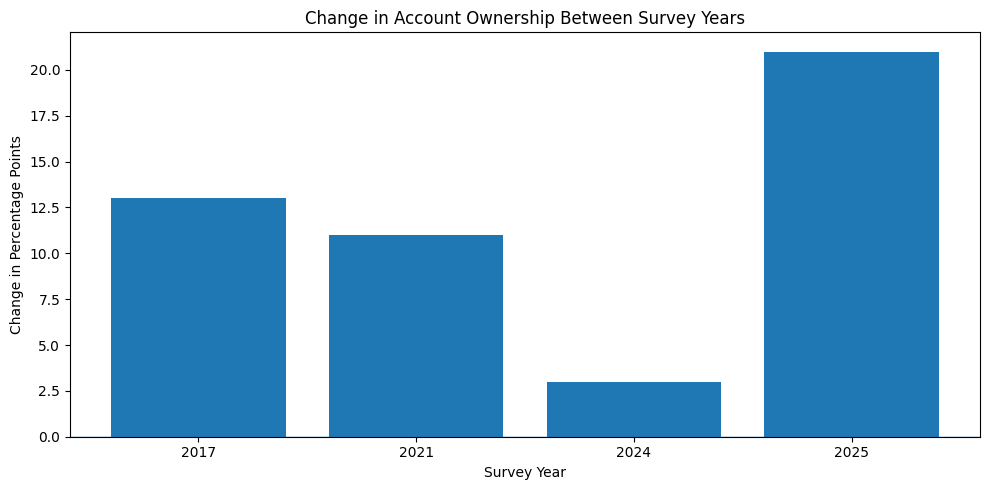

In [31]:
growth_data = account_ownership_national.dropna(
    subset=["absolute_change_pp"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    growth_data["year"].astype(str),
    growth_data["absolute_change_pp"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Change in Account Ownership Between Survey Years"
)

plt.xlabel("Survey Year")
plt.ylabel("Change in Percentage Points")

plt.tight_layout()
plt.show()

## 7. Gender Gap Analysis

In [32]:
gender_ownership = account_ownership[
    account_ownership["gender"].isin(
        ["male", "female"]
    )
].copy()

display(
    gender_ownership[
        [
            "year",
            "gender",
            "value_numeric"
        ]
    ]
)

,year,gender,value_numeric
3,2021,male,56.0
4,2021,female,36.0


In [33]:
gender_pivot = gender_ownership.pivot_table(
    index="year",
    columns="gender",
    values="value_numeric",
    aggfunc="first"
)

display(gender_pivot)

gender,female,male
year,,
2021,36.0,56.0


In [34]:
if {"male", "female"}.issubset(
    gender_pivot.columns
):

    gender_pivot["gender_gap_pp"] = (
        gender_pivot["male"]
        -
        gender_pivot["female"]
    )

    display(gender_pivot)

gender,female,male,gender_gap_pp
year,,,
2021,36.0,56.0,20.0


### Visualization

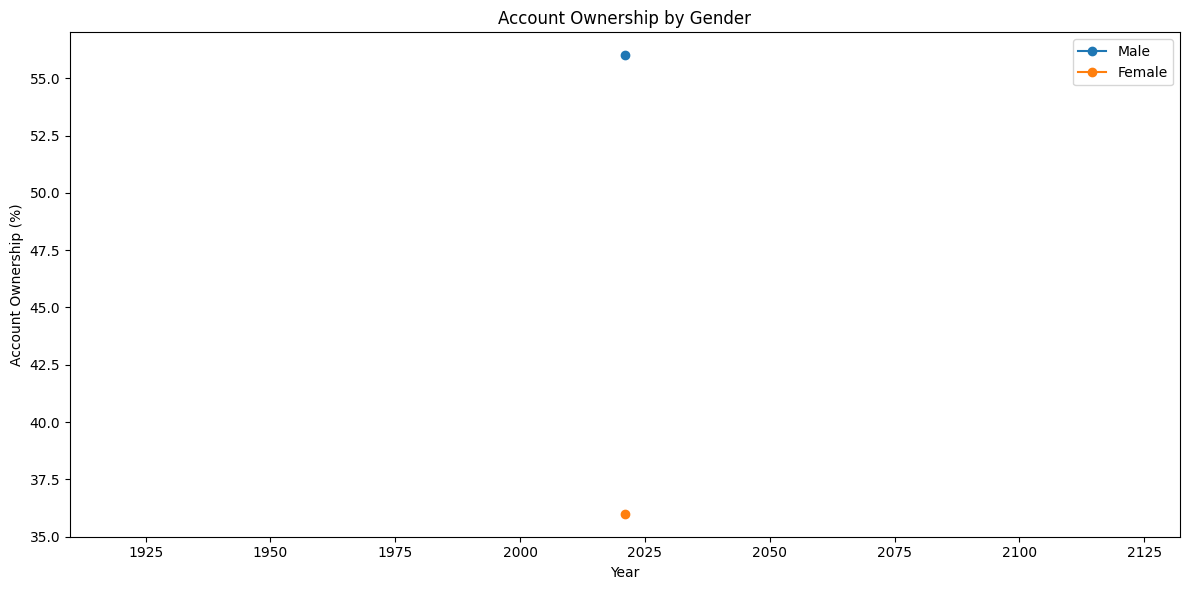

In [35]:
if {"male", "female"}.issubset(
    gender_pivot.columns
):

    plt.figure(figsize=(12, 6))

    plt.plot(
        gender_pivot.index,
        gender_pivot["male"],
        marker="o",
        label="Male"
    )

    plt.plot(
        gender_pivot.index,
        gender_pivot["female"],
        marker="o",
        label="Female"
    )

    plt.title(
        "Account Ownership by Gender"
    )

    plt.xlabel("Year")
    plt.ylabel("Account Ownership (%)")

    plt.legend()

    plt.tight_layout()
    plt.show()

## 9. Investigating the 2021–2024 Slowdown

In [39]:
ownership_growth = account_ownership_national[
    account_ownership_national["year"].isin(
        [2011, 2014, 2017, 2021, 2024]
    )
].copy()

display(
    ownership_growth[
        [
            "year",
            "value_numeric",
            "absolute_change_pp"
        ]
    ]
)

,year,value_numeric,absolute_change_pp
0,2014,22.0,NaN
1,2017,35.0,13.0
2,2021,46.0,11.0
5,2024,49.0,3.0


In [41]:
access_usage_indicators = data[
    data["indicator_code"].isin(
        [
            "ACC_OWNERSHIP",
            "ACC_MOBILE_MONEY",
            "USG_DIGITAL_PAYMENT"
        ]
    )
].copy()

display(
    access_usage_indicators[
        [
            "year",
            "indicator_code",
            "value_numeric",
            "source_name"
        ]
    ].sort_values(
        ["indicator_code", "year"]
    )
)

,year,indicator_code,value_numeric,source_name
0,2014,ACC_OWNERSHIP,22.0,Global Findex 2014
1,2017,ACC_OWNERSHIP,35.0,Global Findex 2017
2,2021,ACC_OWNERSHIP,46.0,Global Findex 2021
3,2021,ACC_OWNERSHIP,56.0,Global Findex 2021
4,2021,ACC_OWNERSHIP,36.0,Global Findex 2021
5,2024,ACC_OWNERSHIP,49.0,Global Findex 2024
30,2025,ACC_OWNERSHIP,70.0,NFIS-II Strategy


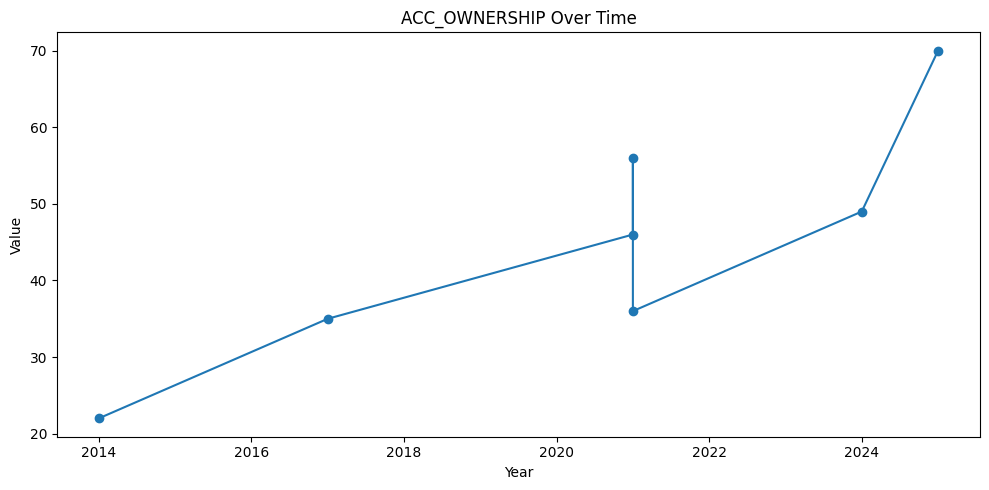

In [42]:
for indicator_code, group in (
    access_usage_indicators
    .groupby("indicator_code")
):

    group = group.sort_values("year")

    plt.figure(figsize=(10, 5))

    plt.plot(
        group["year"],
        group["value_numeric"],
        marker="o"
    )

    plt.title(
        f"{indicator_code} Over Time"
    )

    plt.xlabel("Year")
    plt.ylabel("Value")

    plt.tight_layout()
    plt.show()

## 10. USAGE ANALYSIS

## 10.1 Mobile Money Account Penetration

In [129]:
mobile_money = data[
    data["indicator_code"] == "ACC_MM_ACCOUNT"
].copy()

mobile_money = mobile_money.sort_values(
    "observation_date"
)

display(
    mobile_money[
        [
            "year",
            "value_numeric",
            "gender",
            "location",
            "source_name"
        ]
    ]
)

,year,value_numeric,gender,location,source_name
6,2021,4.70,all,national,Global Findex 2021
7,2024,9.45,all,national,Global Findex 2024


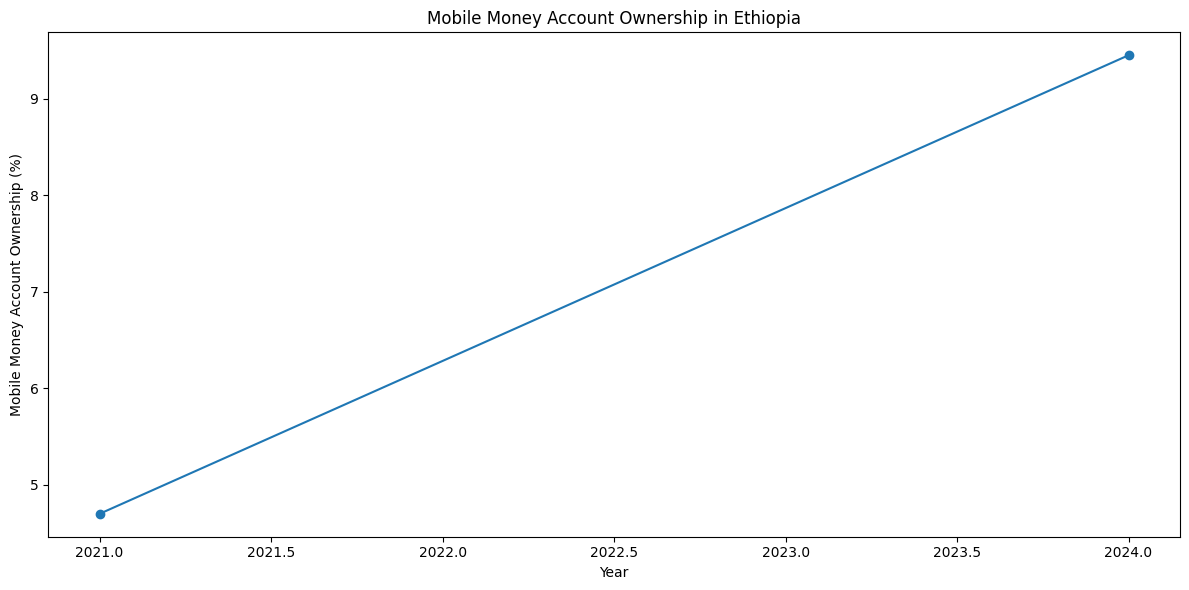

In [130]:
plt.figure(figsize=(12, 6))

plt.plot(
    mobile_money["year"],
    mobile_money["value_numeric"],
    marker="o"
)

plt.title(
    "Mobile Money Account Ownership in Ethiopia"
)

plt.xlabel("Year")
plt.ylabel("Mobile Money Account Ownership (%)")

plt.tight_layout()
plt.show()


## 10.2 Digital Payment Adoption


In [131]:
digital_payments = data[
    data["indicator_code"] == "USG_ACTIVE_RATE"
].copy()

digital_payments = digital_payments.sort_values(
    "observation_date"
)

display(
    digital_payments[
        [
            "year",
            "value_numeric",
            "gender",
            "location",
            "source_name"
        ]
    ]
)


,year,value_numeric,gender,location,source_name
24,2024,66.0,all,national,Calculated


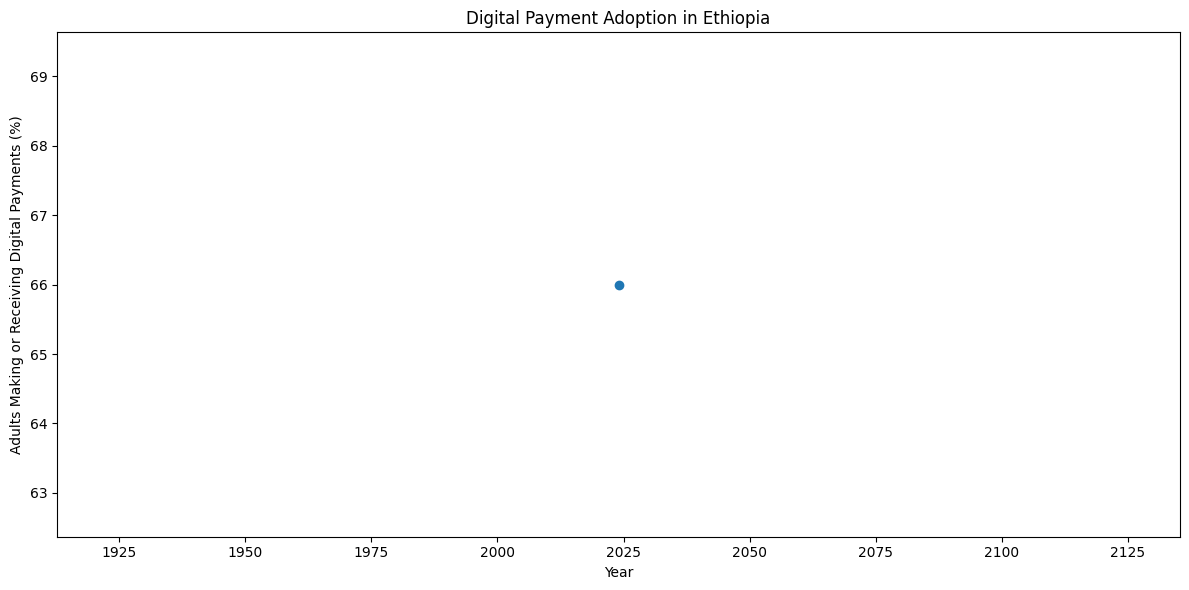

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(
    digital_payments["year"],
    digital_payments["value_numeric"],
    marker="o"
)

plt.title(
    "Digital Payment Adoption in Ethiopia"
)

plt.xlabel("Year")
plt.ylabel("Adults Making or Receiving Digital Payments (%)")

plt.tight_layout()
plt.show()



## 11. Registered vs Active Account Gap



In [81]:
data[
    data["indicator"].astype(str).str.contains(
        "active|registered",
        case=False,
        na=False
    )
][
    [
        "indicator",
        "indicator_code",
        "year",
        "value_numeric",
        "source_name"
    ]
]


,indicator,indicator_code,year,value_numeric,source_name
20,Telebirr Registered Users,USG_TELEBIRR_USERS,2025,54840000.00,Ethio Telecom Report
22,M-Pesa Registered Users,USG_MPESA_USERS,2024,10800000.00,Safaricom Results
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE,2024,7100000.00,Safaricom Results
43,Telebirr Registered Users,TBRR_USERS,2025,54.84,Ethio telecom FY 2024/25 Annual Performance
48,Safaricom Ethiopia 90-Day Active Customers,SAF_ACTIVE_USERS,2025,10.00,Safaricom Ethiopia
53,Safaricom Ethiopia Reaches 10 Million Active C...,NaN,2025,NaN,Safaricom Ethiopia


In [82]:

registered_active = data[
    data["indicator"].astype(str).str.contains(
        "active|registered",
        case=False,
        na=False
    )
].copy()

display(
    registered_active[
        [
            "year",
            "indicator",
            "value_numeric"
        ]
    ].sort_values("year")
)

,year,indicator,value_numeric
22,2024,M-Pesa Registered Users,10800000.00
23,2024,M-Pesa 90-Day Active Users,7100000.00
20,2025,Telebirr Registered Users,54840000.00
43,2025,Telebirr Registered Users,54.84
48,2025,Safaricom Ethiopia 90-Day Active Customers,10.00
53,2025,Safaricom Ethiopia Reaches 10 Million Active C...,NaN


In [137]:
# Example structure if the data contains these two indicators
registered_telebirr = data[
    data["indicator_code"] == "USG_TELEBIRR_USERS"
]
registered_mpesa = data[
    data["indicator_code"] == "USG_MPESA_USERS"
]

registered = pd.concat([registered_telebirr, registered_mpesa], ignore_index=True)

active = data[
    data["indicator_code"] == "USG_ACTIVE_RATE"
]

registered_active_gap = registered.merge(
    active,
    on="year",
    suffixes=("_registered", "_active")
)

registered_active_gap["gap"] = (
    registered_active_gap["value_numeric_registered"]
    -
    registered_active_gap["value_numeric_active"]
)

display(registered_active_gap)

,record_id_registered,record_type_registered,category_registered,pillar_registered,indicator_registered,indicator_code_registered,indicator_direction_registered,value_numeric_registered,value_text_registered,value_type_registered,...,impact_magnitude_active,impact_estimate_active,lag_months_active,evidence_basis_active,comparable_country_active,collected_by_active,collection_date_active,original_text_active,notes_active,gap
0,REC_0023,observation,NaN,USAGE,M-Pesa Registered Users,USG_MPESA_USERS,higher_better,10800000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaT,7.1M / 10.8M = 66%,NaN,10799934.0


## 12. Payment Use Cases

In [84]:
usage_indicators = data[
    data["pillar"] == "USAGE"
][
    [
        "indicator",
        "indicator_code"
    ]
].drop_duplicates()

display(usage_indicators)

,indicator,indicator_code
14,P2P Transaction Count,USG_P2P_COUNT
16,P2P Transaction Value,USG_P2P_VALUE
17,ATM Transaction Count,USG_ATM_COUNT
18,ATM Transaction Value,USG_ATM_VALUE
19,P2P/ATM Crossover Ratio,USG_CROSSOVER
20,Telebirr Registered Users,USG_TELEBIRR_USERS
21,Telebirr Transaction Value,USG_TELEBIRR_VALUE
22,M-Pesa Registered Users,USG_MPESA_USERS
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE
24,Mobile Money Activity Rate,USG_ACTIVE_RATE


In [85]:

use_case_data = data[
    data["indicator"].astype(str).str.contains(
        "P2P|merchant|bill|wage|payment",
        case=False,
        na=False
    )
].copy()

display(
    use_case_data[
        [
            "year",
            "indicator",
            "indicator_code",
            "value_numeric",
            "source_name"
        ]
    ]
)

,year,indicator,indicator_code,value_numeric,source_name
14,2024,P2P Transaction Count,USG_P2P_COUNT,4.970000e+07,EthSwitch Annual Report
15,2025,P2P Transaction Count,USG_P2P_COUNT,1.283000e+08,EthSwitch Annual Report
16,2025,P2P Transaction Value,USG_P2P_VALUE,5.777000e+11,EthSwitch Annual Report
19,2025,P2P/ATM Crossover Ratio,USG_CROSSOVER,1.080000e+00,Calculated
38,2024,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,NaN,EthSwitch
40,2025,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,NaN,NBE/EthSwitch
45,2025,Telebirr Merchants,TBRR_MERCHANTS,3.101000e+05,Ethio telecom FY 2024/25 Annual Performance
51,2025,National Digital Payments Strategy 2.0 Launched,NaN,NaN,National Bank of Ethiopia
52,2024,National Interoperable QR Payment Standard Int...,NaN,NaN,National Bank of Ethiopia
54,2025,National Digital Payments Strategy 2026-2030 D...,NaN,NaN,Ethiopia Digital Payment Conference / NBE


## 13. INFRASTRUCTURE AND ENABLERS

### 13.1 Identify Infrastructure Indicators

In [86]:
infrastructure_keywords = (
    "4G|mobile|internet|ATM|agent|branch|"
    "POS|QR|smartphone|electricity|digital ID"
)

infrastructure_data = data[
    data["indicator"].astype(str).str.contains(
        infrastructure_keywords,
        case=False,
        na=False
    )
].copy()

display(
    infrastructure_data[
        [
            "year",
            "pillar",
            "indicator",
            "indicator_code",
            "value_numeric",
            "value_type",
            "source_name"
        ]
    ].sort_values(
        ["indicator_code", "year"]
    )
)

,year,pillar,indicator,indicator_code,value_numeric,value_type,source_name
8,2023,ACCESS,4G Population Coverage,ACC_4G_COV,3.750000e+01,percentage,Ethio Telecom LEAD Report
9,2025,ACCESS,4G Population Coverage,ACC_4G_COV,7.080000e+01,percentage,Ethio Telecom LEAD Report
11,2024,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,8.000000e+06,count,Fayda Official
12,2025,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,1.200000e+07,count,World Bank
13,2025,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,1.500000e+07,count,ID4Africa Conference
31,2028,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,9.000000e+07,count,Fayda/NIDP
6,2021,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,4.700000e+00,percentage,Global Findex 2021
7,2024,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,9.450000e+00,percentage,Global Findex 2024
10,2025,ACCESS,Mobile Subscription Penetration,ACC_MOBILE_PEN,6.140000e+01,percentage,DataReportal Digital 2026
38,2024,NaN,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,NaN,categorical,EthSwitch


## 13.2 Plot Available Infrastructure Indicators

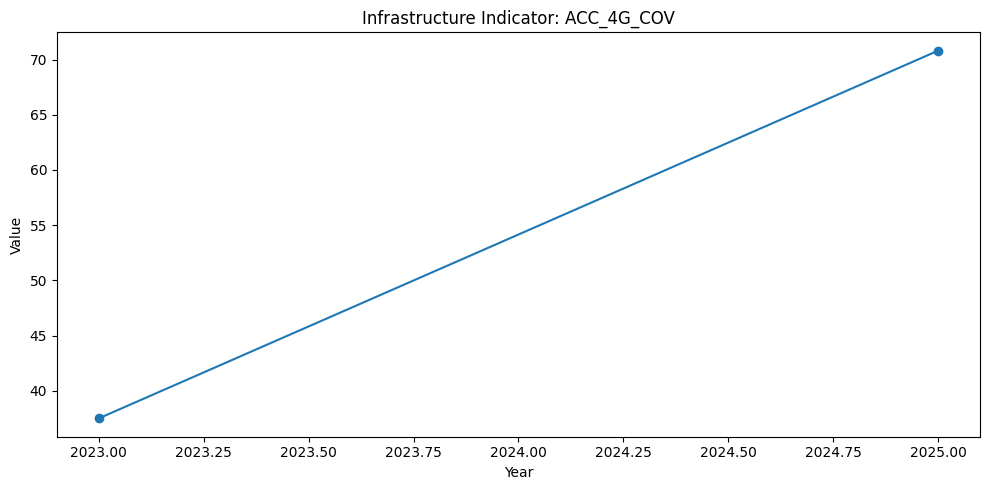

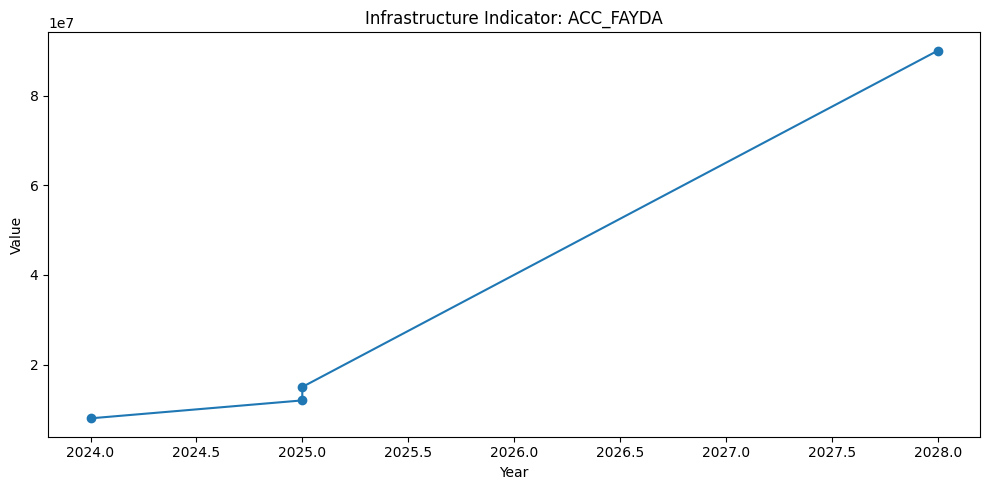

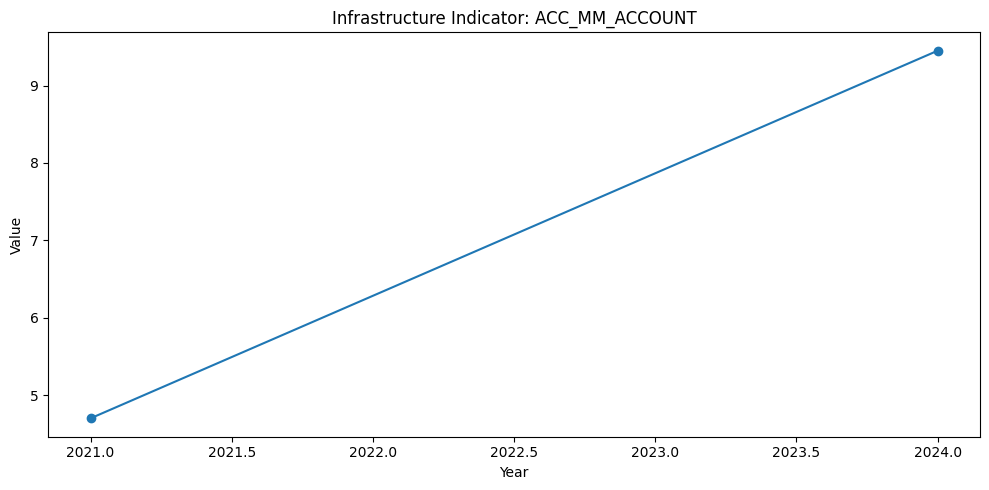

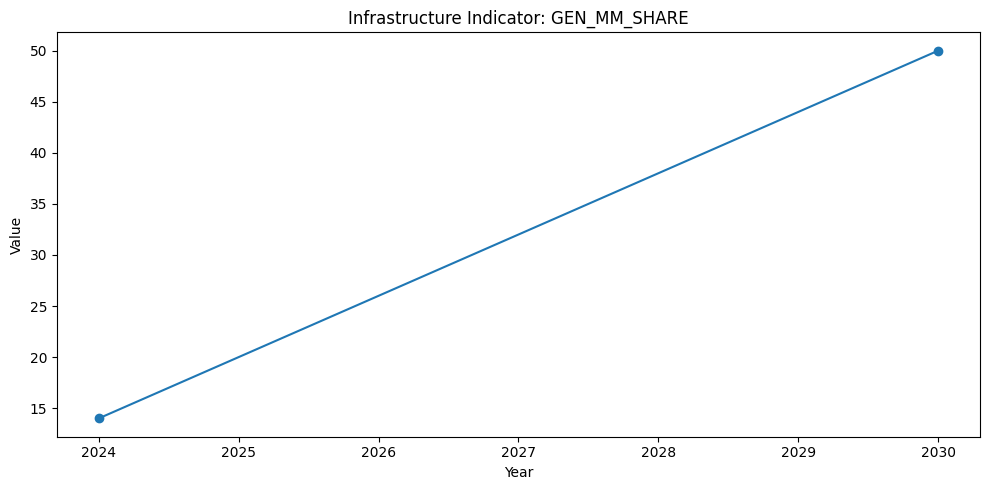

In [87]:
for indicator_code, group in (
    infrastructure_data
    .groupby("indicator_code")
):

    group = group.sort_values("year")

    if group["year"].notna().sum() >= 2:

        plt.figure(figsize=(10, 5))

        plt.plot(
            group["year"],
            group["value_numeric"],
            marker="o"
        )

        plt.title(
            f"Infrastructure Indicator: {indicator_code}"
        )

        plt.xlabel("Year")
        plt.ylabel("Value")

        plt.tight_layout()
        plt.show()

## 14. Relationships Between Infrastructure and Inclusion

In [88]:
analysis_data = data[
    data["record_type"] == "observation"
].copy()

analysis_data["year"] = (
    analysis_data["observation_date"]
    .dt.year
)

In [89]:
indicator_yearly = analysis_data.pivot_table(
    index="year",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean"
)

display(indicator_yearly)

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,MOBILE_MONEY_ACCOUNTS,...,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
year,,,,,,,,,,,,,,,,,,,,,
2014,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,NaN,NaN,4.70,NaN,46.0,NaN,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,NaN,8000000.0,9.45,NaN,49.0,2.0,18.0,24.0,14.0,128.5,...,66.0,NaN,NaN,NaN,7100000.0,10800000.0,49700000.0,NaN,NaN,NaN
2025,70.8,13500000.0,NaN,61.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,119300000.0,1.561000e+11,1.08,NaN,NaN,128300000.0,5.777000e+11,54840000.0,2.380000e+12


In [90]:
correlation_matrix = (
    indicator_yearly
    .corr()
)

display(correlation_matrix)

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,MOBILE_MONEY_ACCOUNTS,...,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
indicator_code,,,,,,,,,,,,,,,,,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
ACC_MM_ACCOUNT,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_MOBILE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_MM_SHARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Correlation with Access

In [91]:
if "ACC_OWNERSHIP" in correlation_matrix.columns:

    access_correlations = (
        correlation_matrix["ACC_OWNERSHIP"]
        .sort_values(
            ascending=False
        )
    )

    display(access_correlations)

indicator_code
ACC_OWNERSHIP                 1.0
ACC_MM_ACCOUNT                1.0
GEN_GAP_ACC                  -1.0
ACC_4G_COV                    NaN
ACC_FAYDA                     NaN
ACC_MOBILE_PEN                NaN
AFF_DATA_INCOME               NaN
GEN_GAP_MOBILE                NaN
GEN_MM_SHARE                  NaN
MOBILE_MONEY_ACCOUNTS         NaN
NATIONAL_DIGITAL_TXN_VALUE    NaN
SAF_ACTIVE_USERS              NaN
TBRR_AGENTS                   NaN
TBRR_MERCHANTS                NaN
TBRR_TXN_VALUE                NaN
TBRR_USERS                    NaN
TBRR_USER_GROWTH              NaN
USG_ACTIVE_RATE               NaN
USG_ATM_COUNT                 NaN
USG_ATM_VALUE                 NaN
USG_CROSSOVER                 NaN
USG_MPESA_ACTIVE              NaN
USG_MPESA_USERS               NaN
USG_P2P_COUNT                 NaN
USG_P2P_VALUE                 NaN
USG_TELEBIRR_USERS            NaN
USG_TELEBIRR_VALUE            NaN
Name: ACC_OWNERSHIP, dtype: float64

### Correlation with Usage

In [92]:
if "USG_DIGITAL_PAYMENT" in correlation_matrix.columns:

    usage_correlations = (
        correlation_matrix["USG_DIGITAL_PAYMENT"]
        .sort_values(
            ascending=False
        )
    )

    display(usage_correlations)

## 15. Correlation Heatmap Using Matplotlib

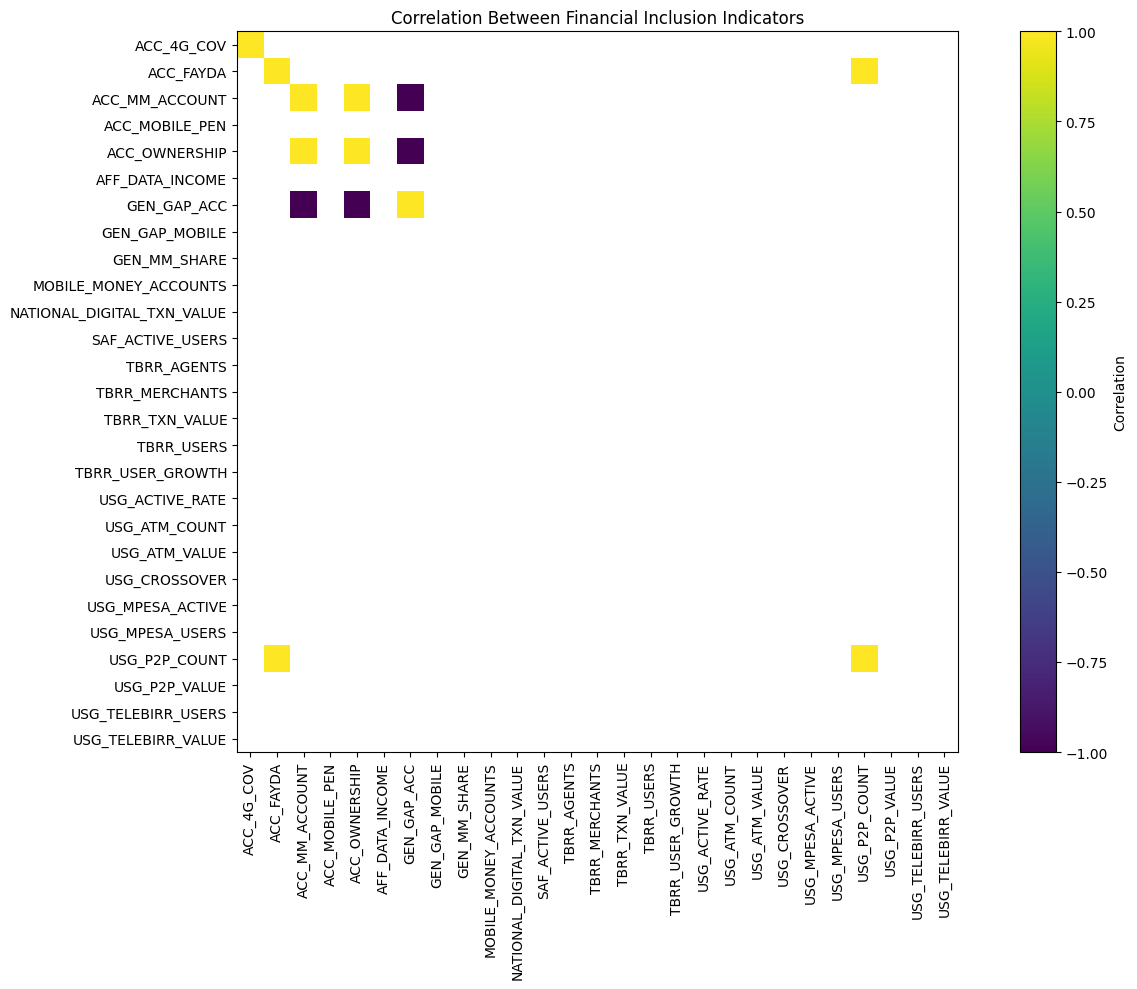

In [93]:
corr = indicator_yearly.corr()

plt.figure(figsize=(14, 10))

plt.imshow(corr)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.title(
    "Correlation Between Financial Inclusion Indicators"
)

plt.tight_layout()
plt.show()

## 16. Identify Potential Leading Indicators

In [94]:
leading_indicator_results = []

target_indicators = [
    "ACC_OWNERSHIP",
    "USG_DIGITAL_PAYMENT"
]

for target in target_indicators:

    if target not in indicator_yearly.columns:
        continue

    for candidate in indicator_yearly.columns:

        if candidate == target:
            continue

        temp = indicator_yearly[
            [
                candidate,
                target
            ]
        ].copy()

        # Candidate from previous year
        temp["candidate_lag_1"] = (
            temp[candidate]
            .shift(1)
        )

        correlation = (
            temp[
                [
                    "candidate_lag_1",
                    target
                ]
            ]
            .corr()
            .iloc[0, 1]
        )

        leading_indicator_results.append(
            {
                "target": target,
                "candidate_indicator": candidate,
                "lag_years": 1,
                "correlation": correlation
            }
        )

leading_indicators = pd.DataFrame(
    leading_indicator_results
)

display(
    leading_indicators.sort_values(
        "correlation",
        ascending=False
    )
)

,target,candidate_indicator,lag_years,correlation
0,ACC_OWNERSHIP,ACC_4G_COV,1,NaN
1,ACC_OWNERSHIP,ACC_FAYDA,1,NaN
2,ACC_OWNERSHIP,ACC_MM_ACCOUNT,1,NaN
3,ACC_OWNERSHIP,ACC_MOBILE_PEN,1,NaN
4,ACC_OWNERSHIP,AFF_DATA_INCOME,1,NaN
5,ACC_OWNERSHIP,GEN_GAP_ACC,1,NaN
6,ACC_OWNERSHIP,GEN_GAP_MOBILE,1,NaN
7,ACC_OWNERSHIP,GEN_MM_SHARE,1,NaN
8,ACC_OWNERSHIP,MOBILE_MONEY_ACCOUNTS,1,NaN
9,ACC_OWNERSHIP,NATIONAL_DIGITAL_TXN_VALUE,1,NaN


## 17. Event Timeline and Visual Analysis

### 17.1 Extract All Cataloged Events

In [96]:
events = data[
    data["record_type"] == "event"
].copy()

events["event_date"] = pd.to_datetime(
    events["observation_date"],
    errors="coerce"
)

events = events.sort_values(
    "event_date"
)

print(f"Number of cataloged events: {len(events)}")

display(
    events[
        [
            "record_id",
            "indicator",
            "category",
            "event_date",
            "source_name",
            "confidence"
        ]
    ]
)

Number of cataloged events: 12


,record_id,indicator,category,event_date,source_name,confidence
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01,NBE,high
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,Safaricom,high
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,NIDP,high
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29,NBE,high
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01,EthSwitch,high
52,EVT_ENRICH_002,National Interoperable QR Payment Standard Int...,infrastructure,2024-12-31,National Bank of Ethiopia,high
51,EVT_ENRICH_001,National Digital Payments Strategy 2.0 Launched,policy,2025-03-28,National Bank of Ethiopia,high
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27,EthSwitch,high


### 17.2 Event Category Distribution

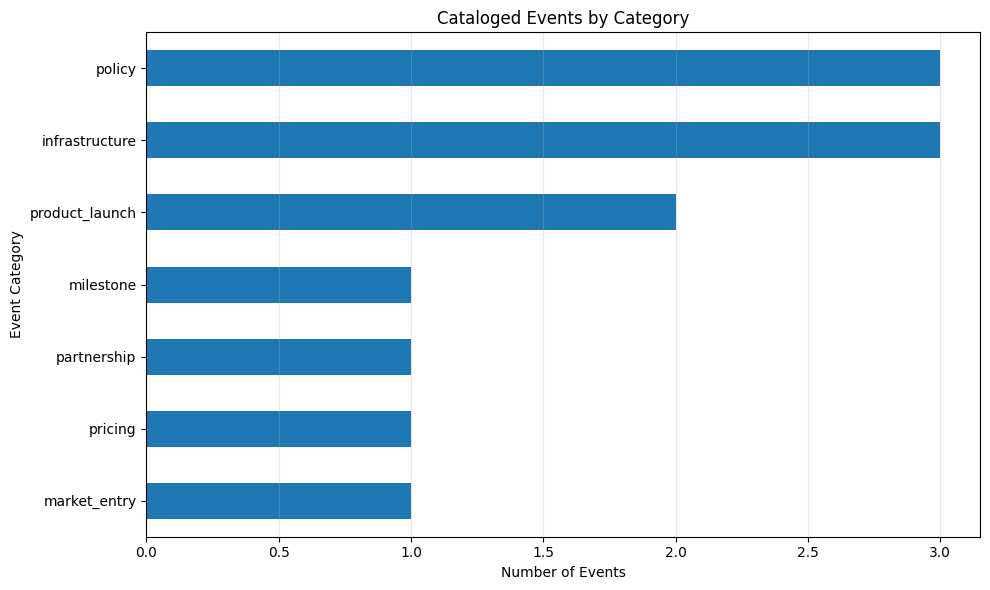

In [97]:
event_category_counts = (
    events["category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

event_category_counts.plot(
    kind="barh"
)

plt.title("Cataloged Events by Category")
plt.xlabel("Number of Events")
plt.ylabel("Event Category")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 17.3 Timeline of All Cataloged Events

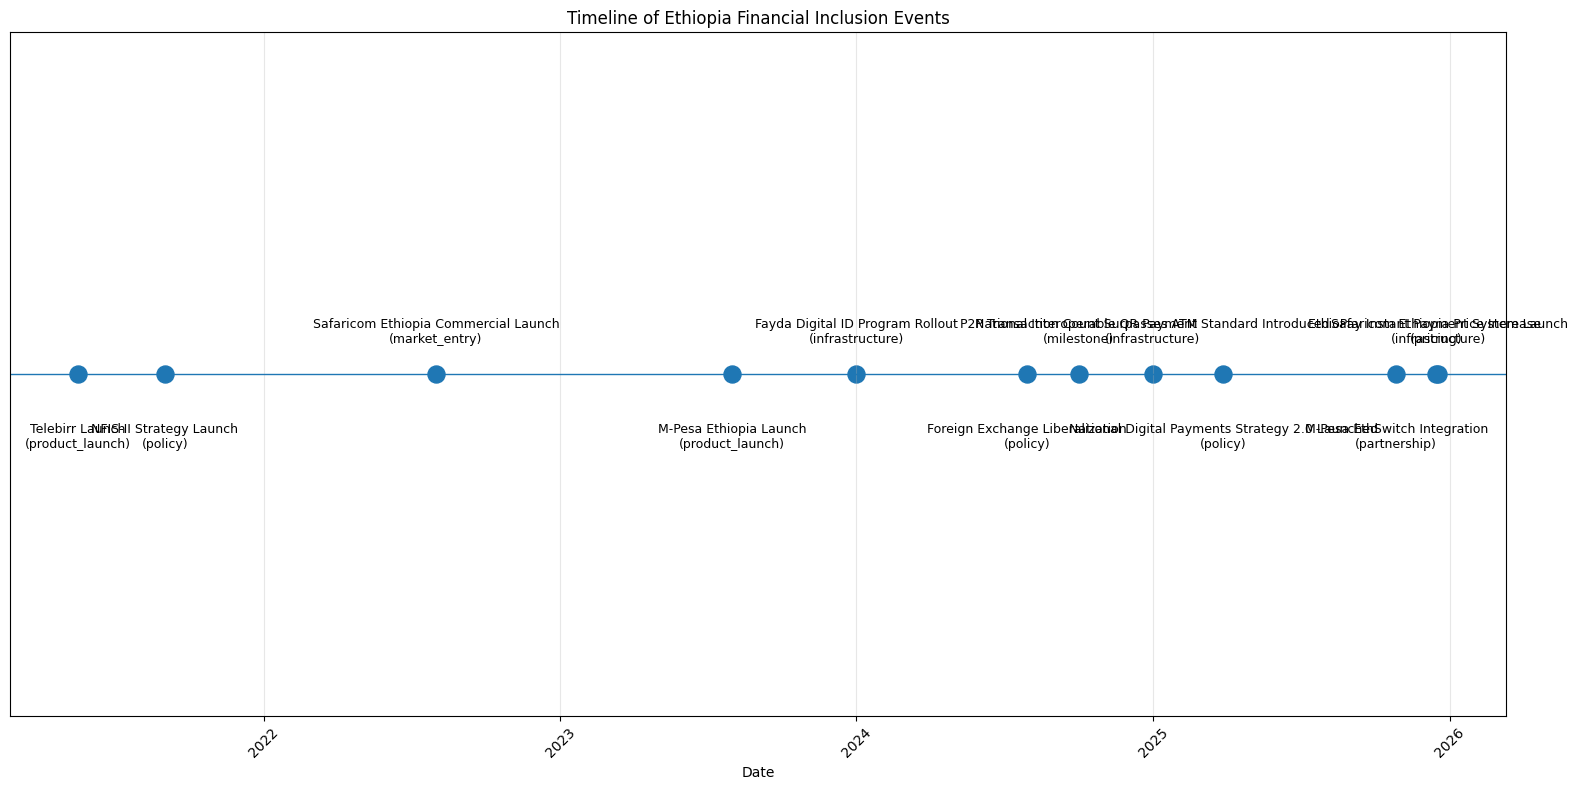

In [100]:
plt.figure(figsize=(16, 8))

# Plot all events on the same horizontal line
plt.scatter(
    events["event_date"],
    np.zeros(len(events)),
    s=150
)

for _, event in events.iterrows():

    event_date = event["event_date"]

    event_name = str(
        event["indicator"]
    )

    category = str(
        event["category"]
    )

    plt.annotate(
        f"{event_name}\n({category})",
        xy=(event_date, 0),
        xytext=(0, 20 if _ % 2 == 0 else -35),
        textcoords="offset points",
        ha="center",
        va="bottom" if _ % 2 == 0 else "top",
        fontsize=9,
        rotation=0
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.yticks([])

plt.title(
    "Timeline of Ethiopia Financial Inclusion Events"
)

plt.xlabel("Date")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.gca().xaxis.set_major_locator(
    mdates.YearLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### 17.4 Display the Event Timeline as a Table

In [101]:
event_timeline = events[
    [
        "record_id",
        "event_date",
        "indicator",
        "category",
        "source_name",
        "confidence",
        "notes"
    ]
].sort_values(
    "event_date"
)

display(event_timeline)

,record_id,event_date,indicator,category,source_name,confidence,notes
33,EVT_0001,2021-05-17,Telebirr Launch,product_launch,Ethio Telecom,high,NaN
41,EVT_0009,2021-09-01,NFIS-II Strategy Launch,policy,NBE,high,NaN
34,EVT_0002,2022-08-01,Safaricom Ethiopia Commercial Launch,market_entry,News,high,NaN
35,EVT_0003,2023-08-01,M-Pesa Ethiopia Launch,product_launch,Safaricom,high,NaN
36,EVT_0004,2024-01-01,Fayda Digital ID Program Rollout,infrastructure,NIDP,high,NaN
37,EVT_0005,2024-07-29,Foreign Exchange Liberalization,policy,NBE,high,NaN
38,EVT_0006,2024-10-01,P2P Transaction Count Surpasses ATM,milestone,EthSwitch,high,NaN
52,EVT_ENRICH_002,2024-12-31,National Interoperable QR Payment Standard Int...,infrastructure,National Bank of Ethiopia,high,Interoperable QR infrastructure can reduce fra...
51,EVT_ENRICH_001,2025-03-28,National Digital Payments Strategy 2.0 Launched,policy,National Bank of Ethiopia,high,Major national policy event focused on interop...
39,EVT_0007,2025-10-27,M-Pesa EthSwitch Integration,partnership,EthSwitch,high,NaN


### 17.5 Identify Important Events

In [ ]:
important_events = events[
    events["indicator"]
    .astype(str)
    .str.contains(
        "Telebirr|Safaricom|M-Pesa|M-Pesa Ethiopia",
        case=False,
        na=False
    )
].copy()

display(
    important_events[
        [
            "record_id",
            "indicator",
            "category",
            "event_date",
            "source_name"
        ]
    ]
)

,record_id,indicator,category,event_date,source_name
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,Safaricom
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27,EthSwitch
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15,News


### 17.6 Account Ownership Trend


In [105]:
account_ownership = data[
    (
        data["record_type"] == "observation"
    )
    &
    (
        data["indicator_code"] == "ACC_OWNERSHIP"
    )
    &
    (
        data["gender"] == "all"
    )
    &
    (
        data["location"] == "national"
    )
].copy()

account_ownership = account_ownership.sort_values(
    "observation_date"
)

display(
    account_ownership[
        [
            "observation_date",
            "value_numeric",
            "source_name"
        ]
    ]
)

,observation_date,value_numeric,source_name
0,2014-12-31,22.0,Global Findex 2014
1,2017-12-31,35.0,Global Findex 2017
2,2021-12-31,46.0,Global Findex 2021
5,2024-11-29,49.0,Global Findex 2024


### 17.7 Account Ownership with Event Overlay

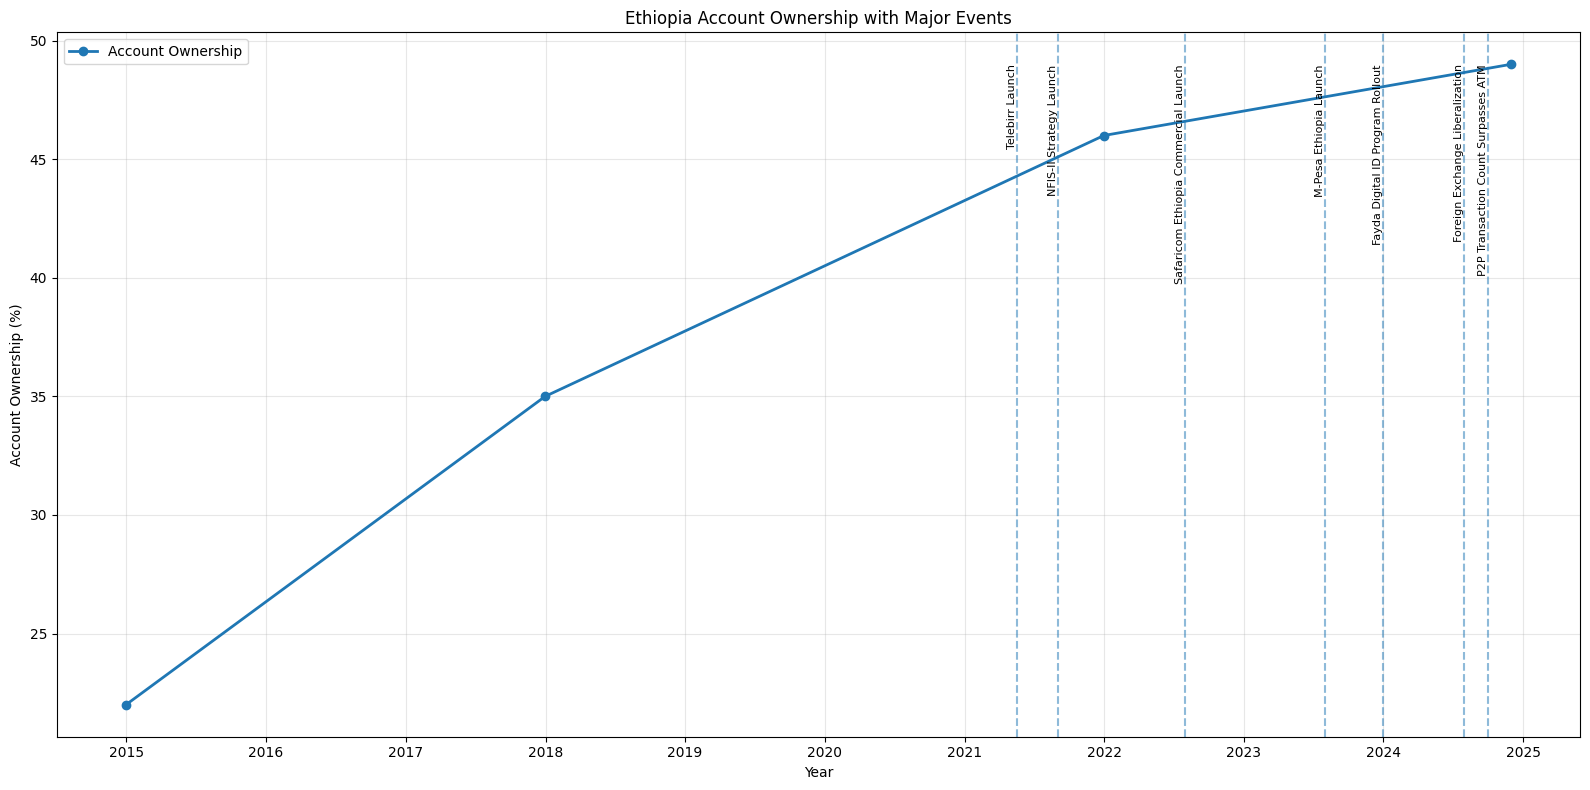

In [106]:
plt.figure(figsize=(16, 8))

# Plot account ownership
plt.plot(
    account_ownership["observation_date"],
    account_ownership["value_numeric"],
    marker="o",
    linewidth=2,
    label="Account Ownership"
)

# Overlay all events
for _, event in events.iterrows():

    event_date = event["event_date"]

    # Only overlay events within the chart's time range
    if (
        event_date >= account_ownership["observation_date"].min()
        and
        event_date <= account_ownership["observation_date"].max()
    ):

        plt.axvline(
            event_date,
            linestyle="--",
            alpha=0.5
        )

        plt.text(
            event_date,
            account_ownership["value_numeric"].max(),
            str(event["indicator"]),
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=8
        )

plt.title(
    "Ethiopia Account Ownership with Major Events"
)

plt.xlabel("Year")

plt.ylabel(
    "Account Ownership (%)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### 17.8 Focused Visualization: Telebirr Launch

In [107]:
telebirr_event = events[
    events["indicator"]
    .astype(str)
    .str.contains(
        "Telebirr",
        case=False,
        na=False
    )
]

display(
    telebirr_event[
        [
            "indicator",
            "event_date",
            "category",
            "source_name"
        ]
    ]
)

,indicator,event_date,category,source_name
33,Telebirr Launch,2021-05-17,product_launch,Ethio Telecom


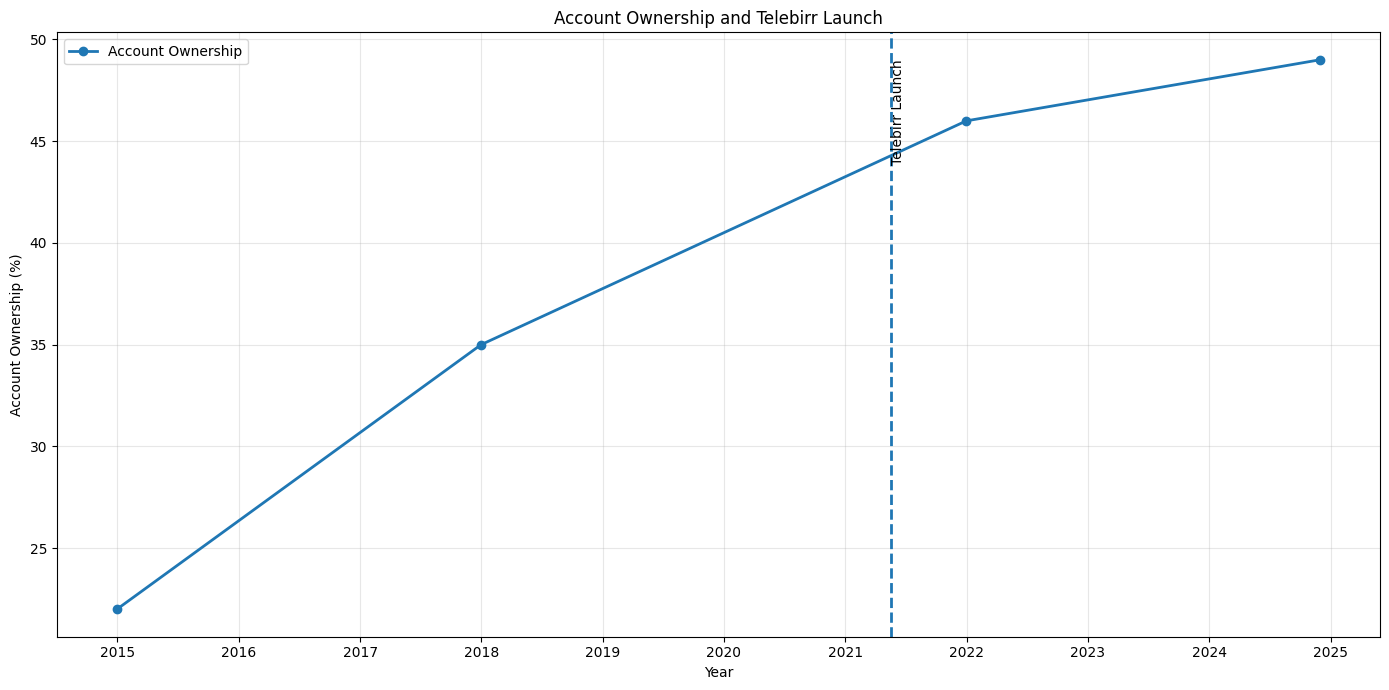

In [108]:
plt.figure(figsize=(14, 7))

plt.plot(
    account_ownership["observation_date"],
    account_ownership["value_numeric"],
    marker="o",
    linewidth=2,
    label="Account Ownership"
)

for _, event in telebirr_event.iterrows():

    plt.axvline(
        event["event_date"],
        linestyle="--",
        linewidth=2
    )

    plt.text(
        event["event_date"],
        account_ownership["value_numeric"].max(),
        "Telebirr Launch",
        rotation=90,
        verticalalignment="top",
        fontsize=10
    )

plt.title(
    "Account Ownership and Telebirr Launch"
)

plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### 17.9 Mobile Money Account Penetration Trend

In [109]:
usage_indicators = data[
    data["pillar"] == "USAGE"
][
    [
        "indicator",
        "indicator_code"
    ]
].drop_duplicates()

display(
    usage_indicators.sort_values(
        "indicator_code"
    )
)

,indicator,indicator_code
49,National Digital Transaction Value,NATIONAL_DIGITAL_TXN_VALUE
45,Telebirr Merchants,TBRR_MERCHANTS
46,Telebirr Annual Electronic Money Transactions,TBRR_TXN_VALUE
24,Mobile Money Activity Rate,USG_ACTIVE_RATE
17,ATM Transaction Count,USG_ATM_COUNT
18,ATM Transaction Value,USG_ATM_VALUE
19,P2P/ATM Crossover Ratio,USG_CROSSOVER
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE
22,M-Pesa Registered Users,USG_MPESA_USERS
14,P2P Transaction Count,USG_P2P_COUNT


In [111]:
mobile_money = data[
    (
        data["record_type"] == "observation"
    )
    &
    (
        data["indicator_code"] == "USG_ACTIVE_RATE"
    )
].copy()

mobile_money = mobile_money.sort_values(
    "observation_date"
)

display(
    mobile_money[
        [
            "observation_date",
            "value_numeric",
            "source_name"
        ]
    ]
)

,observation_date,value_numeric,source_name
24,2024-12-31,66.0,Calculated


### 17.10 Mobile Money Trend with Safaricom and M-Pesa Events

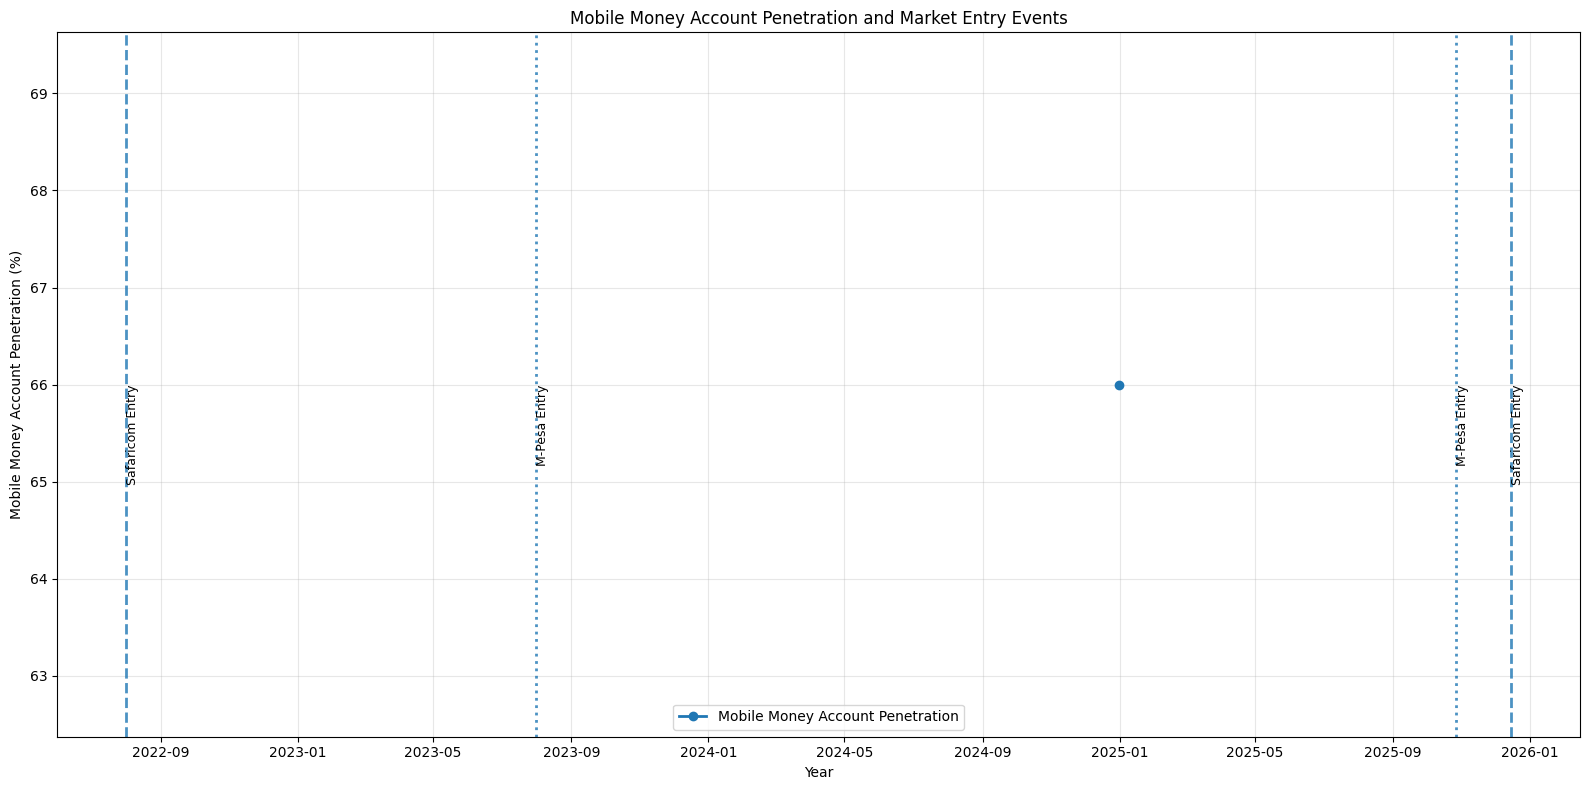

In [112]:
plt.figure(figsize=(16, 8))

plt.plot(
    mobile_money["observation_date"],
    mobile_money["value_numeric"],
    marker="o",
    linewidth=2,
    label="Mobile Money Account Penetration"
)

# Safaricom events
safaricom_events = events[
    events["indicator"]
    .astype(str)
    .str.contains(
        "Safaricom",
        case=False,
        na=False
    )
]

# M-Pesa events
mpesa_events = events[
    events["indicator"]
    .astype(str)
    .str.contains(
        "M-Pesa|M-Pesa Ethiopia",
        case=False,
        na=False
    )
]

for _, event in safaricom_events.iterrows():

    plt.axvline(
        event["event_date"],
        linestyle="--",
        linewidth=2,
        alpha=0.8
    )

    plt.text(
        event["event_date"],
        mobile_money["value_numeric"].max(),
        "Safaricom Entry",
        rotation=90,
        fontsize=9,
        verticalalignment="top"
    )

for _, event in mpesa_events.iterrows():

    plt.axvline(
        event["event_date"],
        linestyle=":",
        linewidth=2,
        alpha=0.8
    )

    plt.text(
        event["event_date"],
        mobile_money["value_numeric"].max(),
        "M-Pesa Entry",
        rotation=90,
        fontsize=9,
        verticalalignment="top"
    )

plt.title(
    "Mobile Money Account Penetration and Market Entry Events"
)

plt.xlabel("Year")
plt.ylabel("Mobile Money Account Penetration (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 17.11 Overlay All Events on the Account Ownership Trend

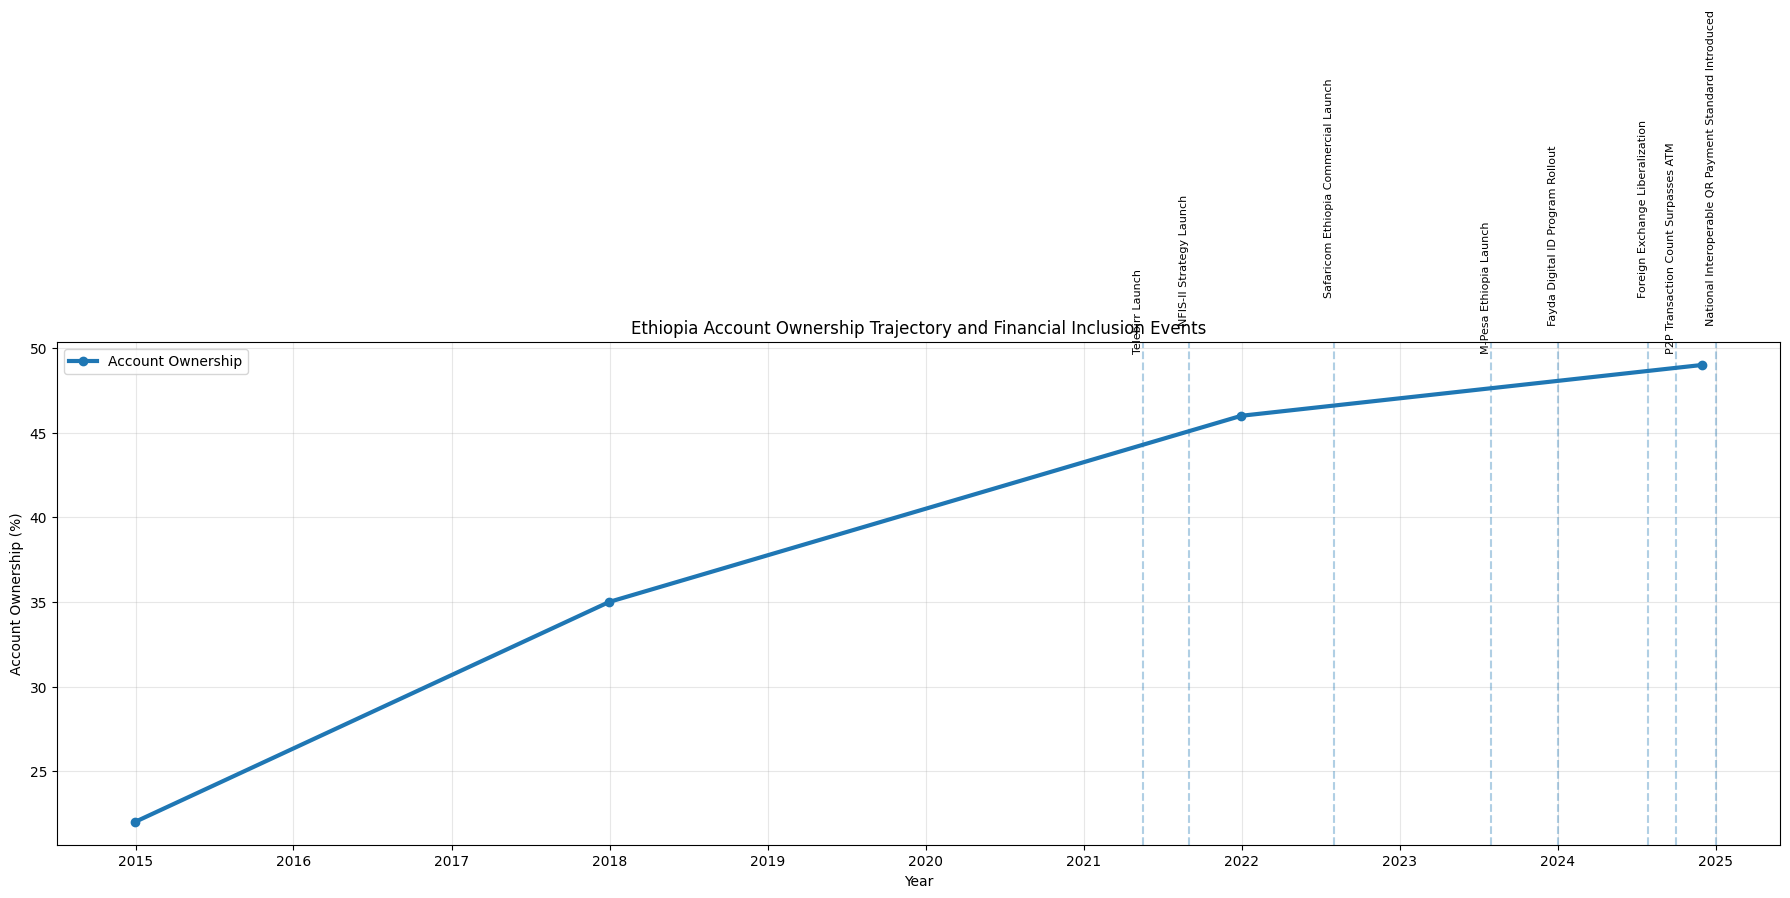

In [113]:
fig, ax = plt.subplots(
    figsize=(18, 9)
)

# Account ownership
ax.plot(
    account_ownership["observation_date"],
    account_ownership["value_numeric"],
    marker="o",
    linewidth=3,
    label="Account Ownership"
)

# All events
for i, (_, event) in enumerate(events.iterrows()):

    event_date = event["event_date"]

    if pd.isna(event_date):
        continue

    # Only show events inside the relevant period
    if (
        event_date >= account_ownership["observation_date"].min()
        and
        event_date <= pd.Timestamp("2024-12-31")
    ):

        ax.axvline(
            event_date,
            linestyle="--",
            alpha=0.35
        )

        ax.annotate(
            str(event["indicator"]),
            xy=(
                event_date,
                account_ownership["value_numeric"].max()
            ),
            xytext=(
                0,
                10 + (i % 3) * 20
            ),
            textcoords="offset points",
            rotation=90,
            fontsize=8,
            ha="right"
        )

ax.set_title(
    "Ethiopia Account Ownership Trajectory and Financial Inclusion Events"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account Ownership (%)")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### 17.12 Event Impact Links


In [114]:
print("Impact link columns:")
print(impact_links.columns.tolist())

Impact link columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [115]:

impact_links.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20 00:00:00,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20 00:00:00,NaN,Competition typically reduces prices


#### Join Impact Links to Events

In [119]:
event_lookup = events[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date"
    ]
].rename(
    columns={
        "record_id": "event_id",
        "indicator": "event_name",
        "observation_date": "event_date"
    }
)

event_impacts = impact_links.merge(
    event_lookup,
    left_on="parent_id",
    right_on="event_id",
    how="left"
)

display(
    event_impacts[
        [
            "parent_id",
            "event_name",
            "event_date",
            "pillar",
            "related_indicator",
            "relationship_type",
            "impact_direction",
            "impact_magnitude",
            "lag_months",
            "evidence_basis"
        ]
    ]
)

,parent_id,event_name,event_date,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,lag_months,evidence_basis
0,EVT_0001,Telebirr Launch,2021-05-17,ACCESS,ACC_OWNERSHIP,direct,increase,high,12,literature
1,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,direct,increase,high,3,empirical
2,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_P2P_COUNT,direct,increase,high,6,empirical
3,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,ACCESS,ACC_4G_COV,direct,increase,medium,12,empirical
4,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,12,literature
5,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,USAGE,USG_MPESA_USERS,direct,increase,high,3,empirical
6,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,6,theoretical
7,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,24,literature
8,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,GENDER,GEN_GAP_ACC,indirect,decrease,medium,24,literature
9,EVT_0005,Foreign Exchange Liberalization,2024-07-29,AFFORDABILITY,AFF_DATA_INCOME,indirect,increase,high,3,empirical


### 17.13 Analyze the Three Key Events

In [121]:
key_event_impacts = event_impacts[
    event_impacts["event_name"]
    .astype(str)
    .str.contains(
        "Telebirr|Safaricom|M-Pesa",
        case=False,
        na=False
    )
]

display(
    key_event_impacts[
        [
            "event_name",
            "event_date",
            "pillar",
            "related_indicator",
            "relationship_type",
            "impact_direction",
            "impact_magnitude",
            "lag_months",
            "evidence_basis"
        ]
    ]
)

,event_name,event_date,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,lag_months,evidence_basis
0,Telebirr Launch,2021-05-17,ACCESS,ACC_OWNERSHIP,direct,increase,high,12,literature
1,Telebirr Launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,direct,increase,high,3,empirical
2,Telebirr Launch,2021-05-17,USAGE,USG_P2P_COUNT,direct,increase,high,6,empirical
3,Safaricom Ethiopia Commercial Launch,2022-08-01,ACCESS,ACC_4G_COV,direct,increase,medium,12,empirical
4,Safaricom Ethiopia Commercial Launch,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,12,literature
5,M-Pesa Ethiopia Launch,2023-08-01,USAGE,USG_MPESA_USERS,direct,increase,high,3,empirical
6,M-Pesa Ethiopia Launch,2023-08-01,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,6,theoretical
10,M-Pesa EthSwitch Integration,2025-10-27,USAGE,USG_MPESA_ACTIVE,direct,increase,medium,3,literature
11,M-Pesa EthSwitch Integration,2025-10-27,USAGE,USG_P2P_COUNT,direct,increase,medium,3,literature
13,Safaricom Ethiopia Price Increase,2025-12-15,AFFORDABILITY,AFF_DATA_INCOME,direct,increase,low,1,empirical


### 17.14 Event Impact Summary

In [122]:
impact_summary = (
    event_impacts
    .groupby(
        [
            "event_name",
            "pillar",
            "impact_direction",
            "impact_magnitude"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="number_of_impact_links"
    )
)

display(
    impact_summary.sort_values(
        "number_of_impact_links",
        ascending=False
    )
)

,event_name,pillar,impact_direction,impact_magnitude,number_of_impact_links
17,NaN,USAGE,increase,high,3
4,M-Pesa EthSwitch Integration,USAGE,increase,medium,2
14,Telebirr Launch,USAGE,increase,high,2
16,NaN,ACCESS,increase,medium,2
2,Fayda Digital ID Program Rollout,GENDER,decrease,medium,1
0,EthioPay Instant Payment System Launch,USAGE,increase,medium,1
1,Fayda Digital ID Program Rollout,ACCESS,increase,medium,1
7,National Digital Payments Strategy 2.0 Launched,ACCESS,increase,medium,1
3,Foreign Exchange Liberalization,AFFORDABILITY,increase,high,1
5,M-Pesa Ethiopia Launch,ACCESS,increase,medium,1


## Final Summary Table


In [95]:
summary = {
    "Number of records": len(data),
    "Number of observations": (
        data["record_type"]
        .eq("observation")
        .sum()
    ),
    "Number of events": (
        data["record_type"]
        .eq("event")
        .sum()
    ),
    "Number of targets": (
        data["record_type"]
        .eq("target")
        .sum()
    ),
    "Number of unique indicators": (
        data["indicator_code"]
        .nunique()
    ),
    "Earliest observation year": (
        data["year"]
        .min()
    ),
    "Latest observation year": (
        data["year"]
        .max()
    )
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Number of records,57
1,Number of observations,38
2,Number of events,12
3,Number of targets,3
4,Number of unique indicators,37
5,Earliest observation year,2014
6,Latest observation year,2030
